# Rock, Paper, Scissors Classification Model
- 3 classes/poses: rock, paper, scissors
  - 1 sample has 5 * 6  features (for now)?
- Classification neural net

https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/02_pytorch_classification.ipynb#scrollTo=Z2gcR31aHC78

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn

In [2]:
print(torch.__version__)
print(torch._dynamo.__file__)

2.6.0+cu124
/mnt/c/Users/j15t3/Documents/Programming/Capstone/.venv/lib/python3.12/site-packages/torch/_dynamo/__init__.py


## Ablation

https://docs.google.com/spreadsheets/d/1Xy92hWhrxcyvLkxY7Q0RPff1FNVfsLxV0ujrjC6SdFE/edit?gid=427952541#gid=427952541

In [3]:
EPOCHS = 500
STD = 0.03
COPY = 4
HIDDEN = 0 # No consistent hidden layers in other models
DROPOUT = 0.5

N_FOLDS = 5

In [4]:
# os.chdir("/content/drive/MyDrive/Senior/Capstone/new data")
df = pd.read_csv("data/Glove_v2/ALL_RPSdata_NEW.csv")
# df = pd.read_csv("jag_RPS_training_data.csv")
df.head()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18823 entries, 0 to 18822
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       18823 non-null  float64
 1   1       18823 non-null  float64
 2   2       18823 non-null  float64
 3   3       18823 non-null  float64
 4   4       18823 non-null  float64
 5   5       18823 non-null  float64
 6   6       18823 non-null  float64
 7   7       18823 non-null  float64
 8   8       18823 non-null  float64
 9   9       18823 non-null  float64
 10  10      18823 non-null  float64
 11  11      18823 non-null  float64
 12  12      18823 non-null  float64
 13  13      18823 non-null  float64
 14  14      18823 non-null  float64
 15  15      18823 non-null  float64
 16  16      18823 non-null  float64
 17  17      18823 non-null  float64
 18  18      18823 non-null  float64
 19  19      18823 non-null  float64
 20  20      18823 non-null  float64
 21  21      18823 non-null  float64
 22  22      1

In [5]:
def augment_with_noise(df, label_col="label", noise_std=0.01, copies=3):
    feature_cols = df.drop(columns=[label_col]).columns
    augmented_dfs = [df]  # keep original

    for i in range(copies):

        noisy_df = df.copy()

        noise = np.random.normal(
            loc=0,
            scale=noise_std,
            size=noisy_df[feature_cols].shape
        )

        noisy_df[feature_cols] = noisy_df[feature_cols] + noise

        augmented_dfs.append(noisy_df)

    return pd.concat(augmented_dfs, ignore_index=True)

In [6]:
augmented_df = augment_with_noise(
    df,
    label_col="label",
    noise_std=STD,   # adjust noise strength
    copies=COPY
)

print(len(df))
df = augmented_df
print(len(augmented_df))

18823
94115


In [7]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,label
0,0.000477,0.563890,0.403126,0.541880,0.465232,0.589896,0.423629,0.681159,0.072824,0.644847,...,0.580315,0.652680,0.532786,0.441633,0.417565,0.444962,0.598195,0.680757,0.535463,scissors
1,0.000484,0.565635,0.401365,0.543453,0.465467,0.589438,0.425422,0.675725,0.103020,0.632312,...,0.579556,0.652680,0.532020,0.441633,0.419720,0.439943,0.597452,0.680108,0.535996,scissors
2,0.001036,0.570868,0.402246,0.534408,0.466887,0.588980,0.425935,0.668478,0.103020,0.632312,...,0.579623,0.655147,0.530344,0.441633,0.420797,0.441735,0.595900,0.683793,0.536339,scissors
3,0.001039,0.560401,0.403787,0.554463,0.464522,0.588980,0.423116,0.661232,0.090586,0.644847,...,0.580180,0.651705,0.532530,0.439414,0.417026,0.445321,0.598523,0.678936,0.535046,scissors
4,0.001993,0.567379,0.401365,0.539127,0.465940,0.590506,0.425935,0.661232,0.095915,0.637883,...,0.580158,0.653198,0.532931,0.440746,0.419181,0.442452,0.597801,0.680339,0.535730,scissors


In [8]:
# 1. Get your minimum count
min_count = df['label'].value_counts().min()

# 2. Use groupby + sample directly (much more reliable)
df_balanced = (
    df.groupby('label', group_keys=False)
    .sample(n=min_count, random_state=42)
)

# 3. Reset index at the very end
df_balanced = df_balanced.reset_index(drop=True)

# Now this will work
print(df_balanced['label'].value_counts())
df = df_balanced

label
paper       19395
rock        19395
scissors    19395
Name: count, dtype: int64


In [9]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,label
0,0.064654,0.579791,0.373301,0.579104,0.448714,0.737733,0.361308,0.455004,0.497616,0.502203,...,0.830006,0.559082,0.542734,0.359371,0.707854,0.352900,0.736659,0.531781,0.361390,paper
1,0.520554,0.508060,0.462558,0.584327,0.455812,0.593575,0.455270,0.791836,0.374603,0.437150,...,0.594146,0.643891,0.505876,0.357412,0.718359,0.223092,0.535249,0.615686,0.500400,paper
2,0.049549,0.410816,0.386834,0.482894,0.406338,0.580434,0.421835,0.648551,0.575488,0.587744,...,0.599164,0.619494,0.567191,0.455837,0.549569,0.353890,0.606828,0.635513,0.558551,paper
3,0.237822,0.373890,0.371565,0.531679,0.462441,0.513905,0.452206,0.705448,0.565568,0.512648,...,0.565616,0.705658,0.562218,0.404780,0.549853,0.334267,0.630737,0.687325,0.534948,paper
4,0.484219,0.508739,0.378821,0.626354,0.496918,0.561039,0.350638,0.808859,0.361805,0.414840,...,0.640242,0.682103,0.581720,0.400899,0.674026,0.314837,0.592982,0.670572,0.552303,paper


In [10]:
# testing = df.sample(n=1000)
testing = df.sample(n=1000, random_state=42).sort_values(by='label').reset_index(drop=True)
df      = df.drop(testing.index).reset_index(drop=True)
testing = testing.reset_index(drop=True)

print(f"testing: {testing.shape}")
print(f"df:      {df.shape}")

testing: (1000, 50)
df:      (57185, 50)


In [11]:
df_all = df
df_all.label.value_counts()

label
rock        19395
scissors    19395
paper       18395
Name: count, dtype: int64

## Make data and label dfs


In [12]:
# Scramble the rows
df_all = df_all.sample(frac=1).reset_index(drop=True)
# df_all = df_all.drop(columns=["time"])
df_all.head(3)

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,label
0,-0.009310,0.284429,0.350329,0.542866,0.491591,0.642145,0.503441,0.740635,0.602677,0.557391,...,0.670431,0.492639,-0.007121,0.333824,0.409639,0.427380,0.541550,0.645172,0.459758,paper
1,0.280857,0.545137,0.403787,0.546599,0.469489,0.587148,0.423629,0.701087,0.303730,0.488858,...,0.576652,0.654073,0.535665,0.344874,0.763470,0.276802,0.596665,0.681093,0.542186,paper
2,0.381288,0.304269,0.332229,0.407869,0.458994,0.594772,0.410920,0.578538,0.532001,0.956870,...,0.618138,0.650806,0.521995,0.335526,0.493695,0.753046,0.589285,0.779362,0.526411,rock


In [13]:
# # Drop all gyro data
# gyro_cols = [col for col in df_all.columns if "gyro" in col]
# df_all = df_all.drop(columns=gyro_cols)
# # leaves you with 18 features (6 sensors × 3 axes)

In [14]:
labels = df_all["label"] # separate labels df, encode labels
mapping = {'rock': 0, 'paper': 1, 'scissors': 2}
labels = labels.map(mapping)
data = df_all.drop(columns=["label"])

In [15]:
# data into pytorch tensors
X = torch.from_numpy(data.values).type(torch.float)
y = torch.from_numpy(labels.values).type(torch.float)

# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

/tmp/ipykernel_24853/3440746049.py:3: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  y = torch.from_numpy(labels.values).type(torch.float)


'cuda'

# Model

In [16]:
input_features = data.shape[1]
classes = 3 # 3 or 4
hidden_units = HIDDEN
input_features

49

In [17]:
# # MODEL 1
# class RPSModel(nn.Module):
#     def __init__(self, input_features, output_features):
#         super().__init__()
#         self.linear_layer_stack = nn.Sequential(
#             nn.Linear(in_features=input_features, out_features=hidden_units),
#             nn.Dropout(p=DROPOUT), # dropout probability
#             # nn.ReLU(),
#             # nn.Linear(in_features=32, out_features=32),
#             # nn.ReLU(),
#             nn.Linear(in_features=hidden_units, out_features=output_features),
#         )

#     # 3. Define a forward method containing the forward pass computation
#     def forward(self, x):
#         return self.linear_layer_stack(x)

In [18]:
# # MODEL 2
# class RPSModel(nn.Module):
#     def __init__(self, input_features, output_features):
#         super().__init__()
#         self.linear_layer_stack = nn.Sequential(
#             nn.Linear(in_features=input_features, out_features=64),
#             nn.BatchNorm1d(64),
#             nn.ReLU(),
#             nn.Dropout(p=DROPOUT),
#             nn.Linear(in_features=64, out_features=32),
#             nn.BatchNorm1d(32),
#             nn.ReLU(),
#             nn.Dropout(p=DROPOUT),

#             nn.Linear(in_features=32, out_features=3)
#         )

#     # 3. Define a forward method containing the forward pass computation
#     def forward(self, x):
#         return self.linear_layer_stack(x)

In [19]:
# MODEL 3
class RPSModel(nn.Module):
    def __init__(self, input_features, output_features):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=32),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),

            nn.Linear(in_features=32, out_features=16),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),

            nn.Linear(in_features=16, out_features=3)
        )

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        return self.linear_layer_stack(x)

In [20]:
# 4. Create an instance of the model and send it to target device
model_4 = RPSModel(input_features=input_features,
                    output_features=classes).to(device)

# Create a loss function
loss_fn = nn.CrossEntropyLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.1)

# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

#Training

In [21]:
# Generate a random integer between 1 and 100 (inclusive)
random_integer = random.randint(1, 100)
print(f"Random integer: {random_integer}")

Random integer: 58


In [22]:
torch.manual_seed(24)

epochs = EPOCHS

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

y_train = y_train.long()
y_test = y_test.long()

# Track losses
train_losses, test_losses = [], []

for epoch in range(epochs):
    ### Training
    model_4.train()
    y_logits = model_4(X_train)
    y_pred = torch.argmax(y_logits, dim=1)
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_test)
        test_pred = torch.argmax(test_logits, dim=1)
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Record losses
    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.10664, Accuracy: 34.19% | Test loss: 1.10462, Test acc: 34.34%
Epoch: 10 | Loss: 1.09720, Accuracy: 35.11% | Test loss: 1.09491, Test acc: 34.45%
Epoch: 20 | Loss: 1.09146, Accuracy: 35.74% | Test loss: 1.08892, Test acc: 34.81%
Epoch: 30 | Loss: 1.08501, Accuracy: 37.82% | Test loss: 1.08076, Test acc: 36.55%
Epoch: 40 | Loss: 1.07680, Accuracy: 41.19% | Test loss: 1.07065, Test acc: 43.31%
Epoch: 50 | Loss: 1.06562, Accuracy: 44.97% | Test loss: 1.05593, Test acc: 79.37%
Epoch: 60 | Loss: 1.04839, Accuracy: 48.87% | Test loss: 1.03449, Test acc: 81.04%
Epoch: 70 | Loss: 1.02340, Accuracy: 52.62% | Test loss: 1.00420, Test acc: 77.35%
Epoch: 80 | Loss: 0.98994, Accuracy: 56.07% | Test loss: 0.96203, Test acc: 76.07%
Epoch: 90 | Loss: 0.94713, Accuracy: 58.44% | Test loss: 0.90599, Test acc: 76.51%
Epoch: 100 | Loss: 0.89854, Accuracy: 60.45% | Test loss: 0.83903, Test acc: 77.60%
Epoch: 110 | Loss: 0.84715, Accuracy: 62.29% | Test loss: 0.76934, Test acc: 78.59%
Epo

In [32]:
MODEL_PATH = "model_4_weights.pth"
torch.save(model_4.state_dict(), MODEL_PATH)

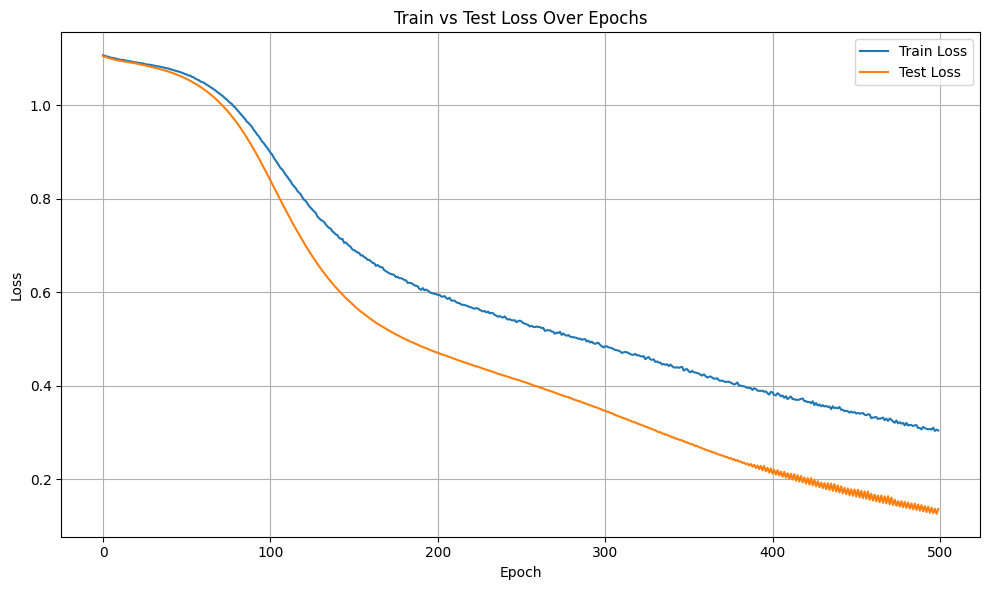

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Testing

In [24]:
testing["label"] = testing["label"].map(mapping)

cmap = plt.cm.get_cmap("gist_rainbow")
num_classes = len(mapping)
colors = cmap(np.linspace(0,1, len(labels)))
labels = ["Rock", "Paper", "Scissors"]

conf_thres = .7

/tmp/ipykernel_24853/1810967289.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("gist_rainbow")


In [25]:
# # Separate features and labels
true_labels = testing['label']
X_features = testing.copy()

X_features = X_features.drop(columns=['label']) # Drop label first

# Ensure all columns are numeric, coercing errors to NaN and filling NaNs with 0
for col in X_features.columns:
    X_features[col] = pd.to_numeric(X_features[col], errors='coerce')
X_features = X_features.fillna(0)

# Align columns with the training data's features
# This step should now work as X_features will have 39 columns (including gyro columns),
# matching the number of columns in `data`.
X_features = X_features[data.columns]

X_new = torch.tensor(X_features.values, dtype=torch.float32).to(device)

# Inference
model_4.eval()
with torch.inference_mode():
    new_logits = model_4(X_new)
    new_pred = torch.argmax(new_logits, dim=1)
    new_probs = torch.softmax(new_logits, dim=1)

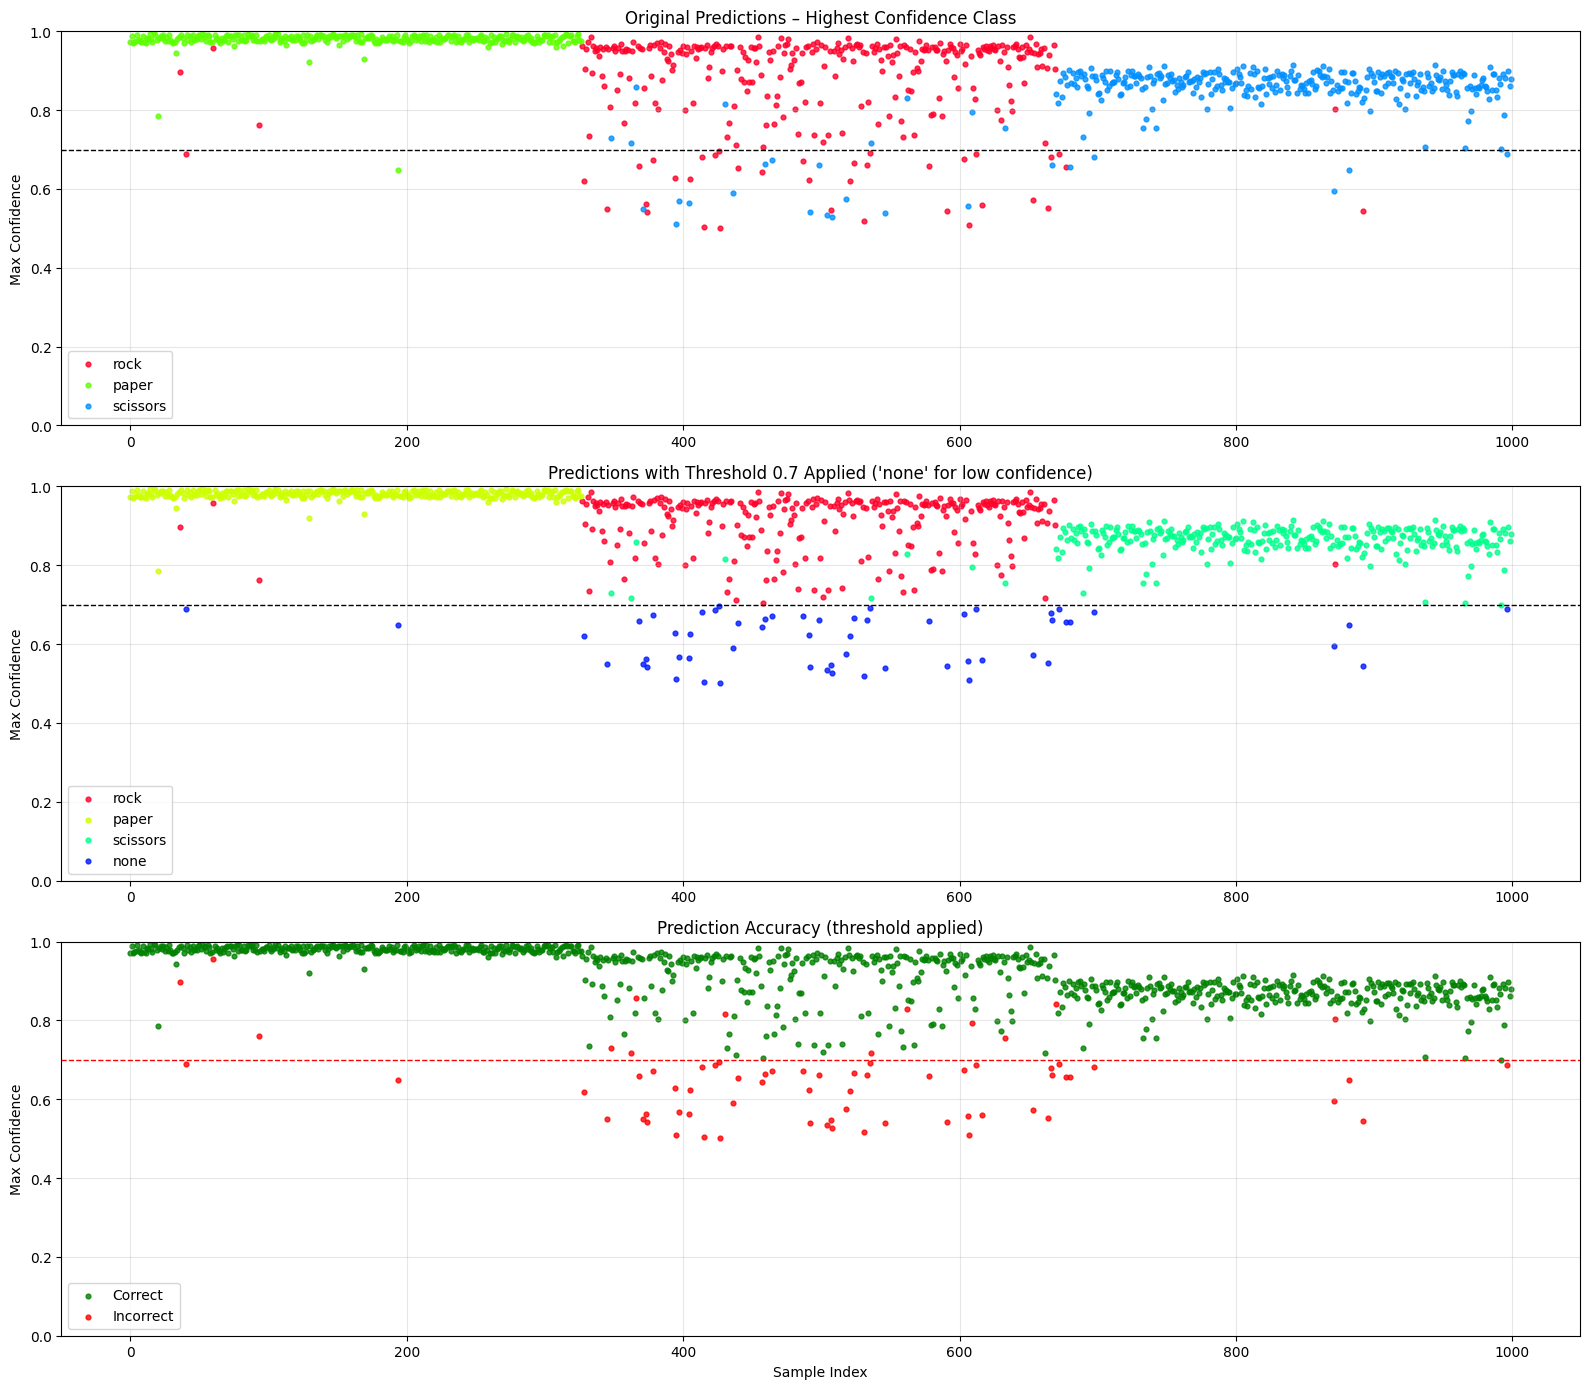

In [26]:
# ------------------------
# Prepare thresholded predictions
# ------------------------
# Convert tensors to CPU numpy
max_probs, max_classes = torch.max(new_probs, dim=1)
max_probs = max_probs.cpu().numpy()
max_classes = max_classes.cpu().numpy()
true_numeric = true_labels.reset_index(drop=True).values

pred_classes_thresh = max_classes.copy()
none_class_idx = len(mapping)  # new class index for "none"
pred_classes_thresh[max_probs < conf_thres] = none_class_idx

all_labels = list(mapping.keys()) + ['none']
num_classes = len(all_labels)

# ------------------------
# Create 3 subplots
# ------------------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16,14))

# ------------------------
# Plot 1: Original max_classes (old graph)
# ------------------------
for class_idx, label in enumerate(mapping.keys()):
    mask = max_classes == class_idx
    indices = np.flatnonzero(mask)
    if len(indices) == 0:
        continue
    color = cmap(class_idx / len(mapping))
    ax1.scatter(
        indices,
        max_probs[indices],
        s=12,
        alpha=0.8,
        label=label,
        color=color
    )

ax1.set_ylabel("Max Confidence")
ax1.set_ylim(0,1)
ax1.set_title("Original Predictions – Highest Confidence Class")
ax1.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax1.legend()
ax1.grid(alpha=0.3)

# ------------------------
# Plot 2: Thresholded predictions (low confidence -> 'none')
# ------------------------
for class_idx, label in enumerate(all_labels):
    mask = pred_classes_thresh == class_idx
    indices = np.flatnonzero(mask)
    if len(indices) == 0:
        continue
    color = cmap(class_idx / num_classes)
    ax2.scatter(
        indices,
        max_probs[indices],
        s=12,
        alpha=0.8,
        label=label,
        color=color
    )

ax2.set_ylabel("Max Confidence")
ax2.set_ylim(0,1)
ax2.set_title(f"Predictions with Threshold {conf_thres} Applied ('none' for low confidence)")
ax2.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax2.legend()
ax2.grid(alpha=0.3)

# ------------------------
# Plot 3: Correct vs Incorrect (threshold applied)
# ------------------------
correct_mask_thresh = pred_classes_thresh == true_numeric
incorrect_mask_thresh = pred_classes_thresh != true_numeric

correct_idx = np.flatnonzero(correct_mask_thresh)
incorrect_idx = np.flatnonzero(incorrect_mask_thresh)

ax3.scatter(
    correct_idx,
    max_probs[correct_idx],
    s=12,
    alpha=0.8,
    label="Correct",
    color="green"
)

ax3.scatter(
    incorrect_idx,
    max_probs[incorrect_idx],
    s=12,
    alpha=0.8,
    label="Incorrect",
    color="red"
)

ax3.set_xlabel("Sample Index")
ax3.set_ylabel("Max Confidence")
ax3.set_ylim(0,1)
ax3.set_title("Prediction Accuracy (threshold applied)")
ax3.axhline(y=conf_thres, color='red', linestyle='--', linewidth=1)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Confusion Matrix

Accuracy: 0.9680 (96.80%)


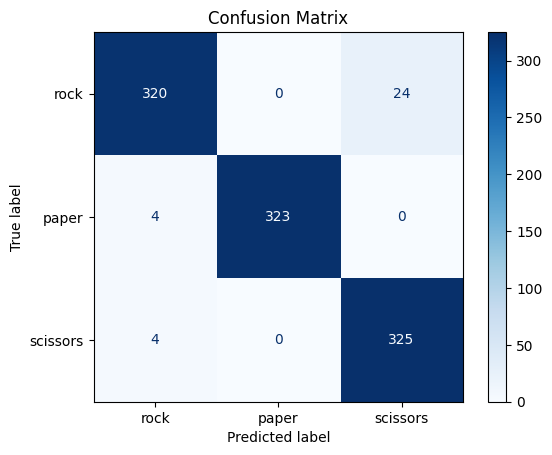

In [27]:
# Accuracy
accuracy = accuracy_score(true_numeric, max_classes)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(true_numeric, max_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(mapping.keys()))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Accuracy (threshold applied): 0.9300 (93.00%)


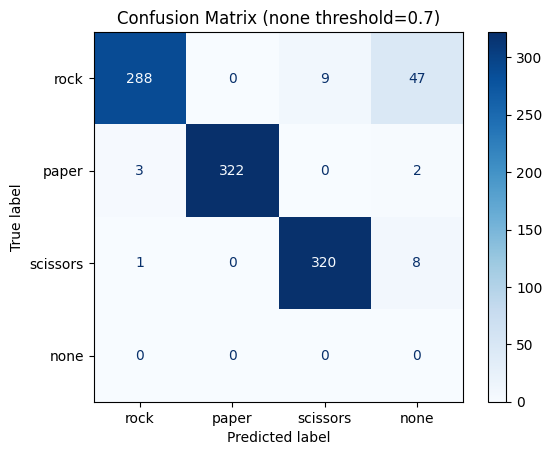

In [28]:
# ------------------------
# Accuracy (threshold applied)
# ------------------------
accuracy_thresh = accuracy_score(true_numeric, pred_classes_thresh)
print(f"Accuracy (threshold applied): {accuracy_thresh:.4f} ({accuracy_thresh*100:.2f}%)")

# ------------------------
# Confusion Matrix with 'none'
# ------------------------
all_labels = list(mapping.keys()) + ['none']  # Include 'none' class

cm_thresh = confusion_matrix(true_numeric, pred_classes_thresh, labels=range(len(all_labels)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_thresh, display_labels=all_labels)
disp.plot(cmap='Blues', xticks_rotation='horizontal')
plt.title(f"Confusion Matrix (none threshold={conf_thres})")
plt.show()

# Evaluation



  FOLD 1 / 5
  Epoch: 0 | Train Loss: 1.10610, Train Acc: 33.21% | Test Loss: 1.09914, Test Acc: 33.90%
  Epoch: 100 | Train Loss: 0.78150, Train Acc: 66.28% | Test Loss: 0.69470, Test Acc: 84.79%
  Epoch: 200 | Train Loss: 0.51872, Train Acc: 76.82% | Test Loss: 0.39152, Test Acc: 91.55%
  Epoch: 300 | Train Loss: 0.38604, Train Acc: 84.56% | Test Loss: 0.22641, Test Acc: 96.64%
  Epoch: 400 | Train Loss: 0.28397, Train Acc: 89.63% | Test Loss: 0.11233, Test Acc: 98.86%
  Epoch: 499 | Train Loss: 0.22467, Train Acc: 91.84% | Test Loss: 0.06185, Test Acc: 99.27%

  FOLD 2 / 5
  Epoch: 0 | Train Loss: 1.11864, Train Acc: 33.82% | Test Loss: 1.11431, Test Acc: 33.92%
  Epoch: 100 | Train Loss: 0.98953, Train Acc: 59.31% | Test Loss: 0.96471, Test Acc: 85.10%
  Epoch: 200 | Train Loss: 0.62506, Train Acc: 74.34% | Test Loss: 0.49724, Test Acc: 90.62%
  Epoch: 300 | Train Loss: 0.46272, Train Acc: 82.28% | Test Loss: 0.29520, Test Acc: 94.89%
  Epoch: 400 | Train Loss: 0.34491, Train Acc:

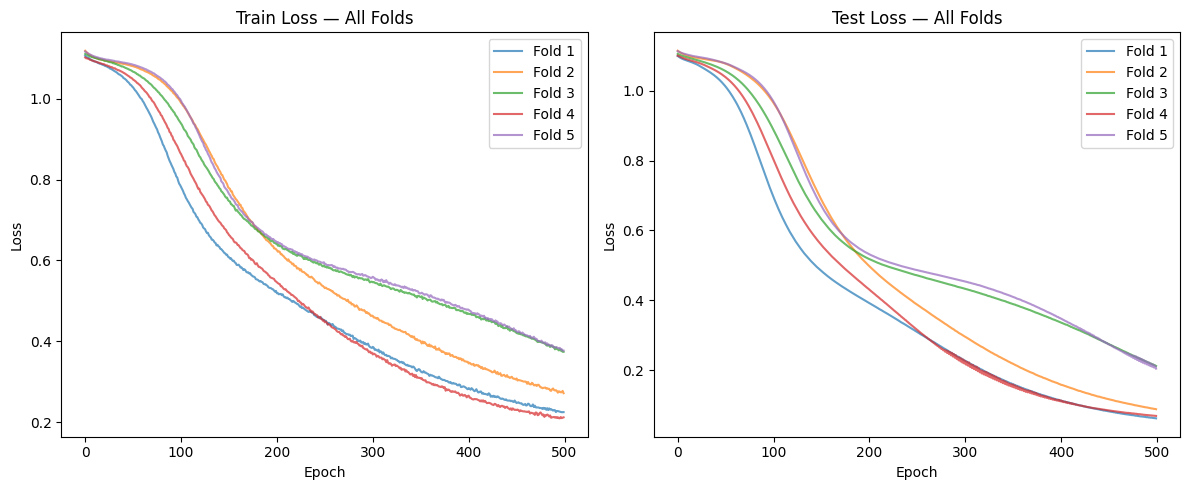


  K-FOLD RESULTS SUMMARY
  Fold 1: Train 91.84%  |  Test 99.27%
  Fold 2: Train 91.05%  |  Test 98.80%
  Fold 3: Train 84.83%  |  Test 96.39%
  Fold 4: Train 93.61%  |  Test 99.44%
  Fold 5: Train 85.33%  |  Test 97.72%

  Mean test acc : 98.32%
  Std  test acc : 1.14%


In [29]:
torch.manual_seed(42)

all_train_losses = [] # Initialize to store epoch-wise train losses for each fold
all_test_losses  = [] # This will now store epoch-wise test losses for each fold

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_train_accs = [] # Initialize to store final train accuracy for each fold
fold_test_accs = [] # This will store final test accuracy for each fold
X_np = X.numpy()
y_np = y.numpy()

for fold, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
    print(f"\n{'='*40}")
    print(f"  FOLD {fold + 1} / {N_FOLDS}")
    print(f"{'='*40}")

    # Split data for the current fold
    X_train_fold, y_train_fold = X[train_idx].to(device), y[train_idx].long().to(device)
    X_test_fold, y_test_fold   = X[test_idx].to(device), y[test_idx].long().to(device)

    # Create a new model for each fold to ensure independent training
    model = RPSModel(input_features=input_features,
                     output_features=classes).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1) # Optimizer needs to be re-initialized too

    train_losses_per_epoch_fold = [] # To store losses for current fold's training
    test_losses_per_epoch_fold = []  # To store losses for current fold's testing
    current_fold_train_acc = 0.0
    current_fold_test_acc = 0.0

    for epoch in range(EPOCHS): # Use EPOCHS from ablation cell
        ### Training
        model.train()
        y_logits = model(X_train_fold)
        y_pred = torch.argmax(y_logits, dim=1)
        loss = loss_fn(y_logits, y_train_fold)
        current_fold_train_acc = accuracy_fn(y_true=y_train_fold, y_pred=y_pred)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### Testing (evaluation during training for this fold)
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test_fold)
            test_pred = torch.argmax(test_logits, dim=1)
            test_loss = loss_fn(test_logits, y_test_fold)
            current_fold_test_acc = accuracy_fn(y_true=y_test_fold, y_pred=test_pred)

        train_losses_per_epoch_fold.append(loss.item())
        test_losses_per_epoch_fold.append(test_loss.item())

        if epoch % 100 == 0 or epoch == EPOCHS - 1: # Print less frequently
            print(f"  Epoch: {epoch} | Train Loss: {loss:.5f}, Train Acc: {current_fold_train_acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {current_fold_test_acc:.2f}%")

    # After training for all epochs in a fold, store the epoch-wise losses and final accuracies
    all_train_losses.append(train_losses_per_epoch_fold)
    all_test_losses.append(test_losses_per_epoch_fold)

    fold_train_accs.append(current_fold_train_acc) # acc from last epoch of training
    fold_test_accs.append(current_fold_test_acc) # test_acc from last epoch of testing

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i, losses in enumerate(all_train_losses):
    plt.plot(losses, label=f'Fold {i+1}', alpha=0.7)
plt.title('Train Loss — All Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for i, losses in enumerate(all_test_losses):
    plt.plot(losses, label=f'Fold {i+1}', alpha=0.7)
plt.title('Test Loss — All Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n{'='*40}")
print(f"  K-FOLD RESULTS SUMMARY")
print(f"{'='*40}")
for i, (tr, te) in enumerate(zip(fold_train_accs, fold_test_accs)):
    print(f"  Fold {i+1}: Train {tr:.2f}%  |  Test {te:.2f}%")
print(f"\n  Mean test acc : {np.mean(fold_test_accs):.2f}%")
print(f"  Std  test acc : {np.std(fold_test_accs):.2f}%")

# Which features are the most important?

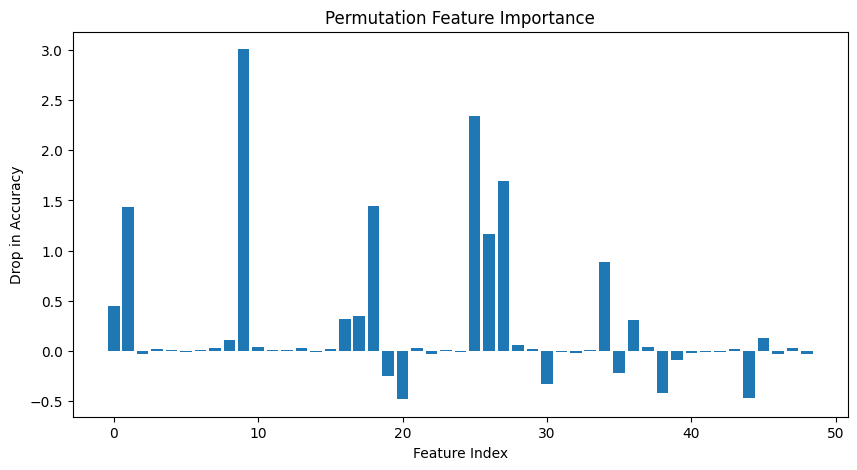

In [30]:
baseline_acc = accuracy_fn(y_true=y_test, y_pred=torch.argmax(model_4(X_test), dim=1))

importances = []
for i in range(X_test.shape[1]):
    X_permuted = X_test.clone()
    X_permuted[:, i] = X_test[torch.randperm(X_test.shape[0]), i]  # shuffle column i

    with torch.inference_mode():
        perm_pred = torch.argmax(model_4(X_permuted), dim=1)

    perm_acc = accuracy_fn(y_true=y_test, y_pred=perm_pred)
    importances.append(baseline_acc - perm_acc)  # drop in accuracy = importance

# Plot
plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances)
plt.xlabel("Feature Index")
plt.ylabel("Drop in Accuracy")
plt.title("Permutation Feature Importance")
plt.show()

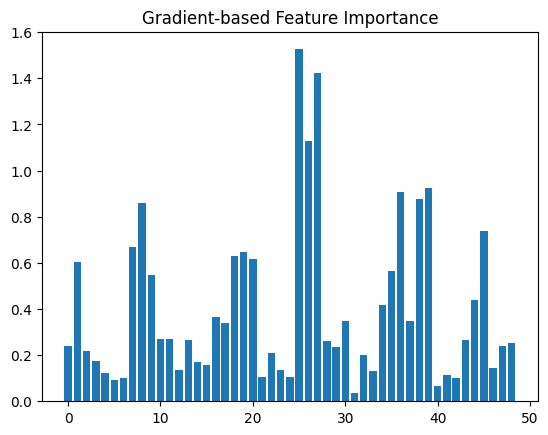

In [31]:
X_test.requires_grad_(True)
output = model_4(X_test)
output.max(dim=1).values.sum().backward()

importances = X_test.grad.abs().mean(dim=0).cpu().detach()

plt.bar(range(len(importances)), importances)
plt.title("Gradient-based Feature Importance")
plt.show()